In [81]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score 
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss 
import numpy as np

In [82]:
matches = pd.read_csv('../data/processed/features_v4.csv')

In [83]:
features = [ 'PPGDiff', 'GoalAgainstDiffLast5', 'ShotOTDiffLast5', 'GDPerGameDiff', 'GoalsAgainstPerGameDiff', 'EloDiff' ]

In [84]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [85]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [86]:
# model = CalibratedClassifierCV(RandomForestClassifier(
#     n_estimators=300,
#     max_depth=6,
#     min_samples_leaf=10,
#     random_state=42,
#     n_jobs=-1
# ), method='isotonic')

model = CalibratedClassifierCV(RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
), method='sigmoid')

# model = GradientBoostingClassifier()

In [87]:
model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...0022C61BBEDF0>, 

In [88]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)

print(model.classes_)

['A' 'D' 'H']


In [89]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.49473684210526314


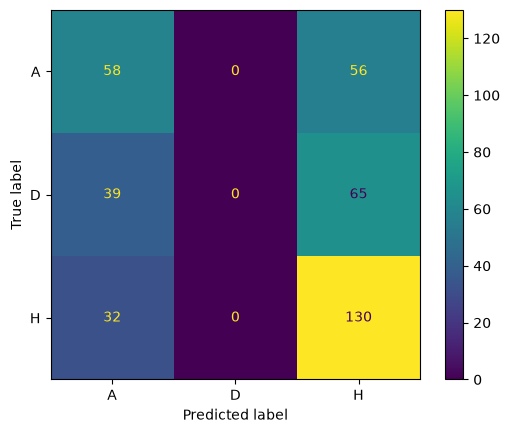

In [90]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [91]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.17519622 0.21015316 0.61465063]


In [92]:
results = test[['HomeTeam', 'AwayTeam', 'FTR']].copy() 
results['Predicted'] = preds 
results['AwayProb'] = probs[:, 0] 
results['DrawProb'] = probs[:, 1] 
results['HomeProb'] = probs[:, 2] 
results.head(10)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,Liverpool,Bournemouth,H,H,0.175196,0.210153,0.614651
1521,Aston Villa,Newcastle,D,H,0.292487,0.228118,0.479395
1522,Brighton,Fulham,D,H,0.209927,0.189651,0.600422
1523,Sunderland,West Ham,H,H,0.294338,0.236240,0.469422
1524,Tottenham,Burnley,H,H,0.230880,0.238999,0.530121
1525,Wolves,Man City,A,A,0.514675,0.219207,0.266118
1526,Chelsea,Crystal Palace,D,H,0.213799,0.228025,0.558176
1527,Nott'm Forest,Brentford,H,H,0.303743,0.221648,0.474609
1528,Man United,Arsenal,A,A,0.469471,0.223611,0.306918
1529,Leeds,Everton,H,A,0.514945,0.220262,0.264793


In [93]:
importances = np.mean(
    [clf.estimator.feature_importances_
     for clf in model.calibrated_classifiers_],
    axis=0
)

importance = pd.Series(
    importances,
    index=features
).sort_values(ascending=False)

print(importance)

EloDiff                    0.274872
PPGDiff                    0.202173
GDPerGameDiff              0.191658
GoalsAgainstPerGameDiff    0.162023
ShotOTDiffLast5            0.104385
GoalAgainstDiffLast5       0.064890
dtype: float64


In [94]:
print(log_loss(y_test, probs))

1.029708770948755


In [95]:
results['MaxProb'] = results[['AwayProb','DrawProb','HomeProb']].max(axis=1) 
results['Correct'] = results['Predicted'] == results['FTR'] 
bins = pd.cut(results['MaxProb'], [0.33,0.45,0.55,0.65,0.75,1.0]) 
results.groupby(bins)['Correct'].agg(['mean','count'])

,mean,count
MaxProb,,
"(0.33, 0.45]",0.486842,76
"(0.45, 0.55]",0.409091,132
"(0.55, 0.65]",0.521008,119
"(0.65, 0.75]",0.647059,51
"(0.75, 1.0]",1.000000,2


In [96]:
results['DrawProb'] = probs[:, 1]

In [97]:
results.sort_values('DrawProb', ascending=False)[
    ['HomeTeam', 'AwayTeam', 'FTR', 'Predicted', 'DrawProb']
].head(20)

,HomeTeam,AwayTeam,FTR,Predicted,DrawProb
1820,Brentford,Wolves,D,H,0.340726
1856,Wolves,Tottenham,A,H,0.336430
1709,Sunderland,Man City,D,A,0.334708
1578,Newcastle,Arsenal,A,A,0.330845
1752,Wolves,Bournemouth,A,A,0.316255
1538,Fulham,Man United,D,H,0.315865
1606,Aston Villa,Man City,H,A,0.311153
1537,Everton,Brighton,H,A,0.309692
1575,Nott'm Forest,Sunderland,A,A,0.308140
1744,Bournemouth,Liverpool,H,A,0.305799


In [98]:
results['DrawProbBin'] = pd.cut(
    results['DrawProb'],
    [0, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 1]
)

results.groupby('DrawProbBin', observed=True).apply(
    lambda x: pd.Series({
        'ActualDrawRate': (x['FTR'] == 'D').mean(),
        'Count': len(x)
    })
)

,ActualDrawRate,Count
DrawProbBin,,
"(0.0, 0.15]",0.285714,7.0
"(0.15, 0.2]",0.237500,80.0
"(0.2, 0.25]",0.252525,198.0
"(0.25, 0.3]",0.358025,81.0
"(0.3, 0.35]",0.285714,14.0
